# 05 - Final Filtering, Export, and Figure-Ready Visualization

This notebook loads intermediate products, applies final ROI filtering/export, and generates publication-oriented QC panels for the filtered calcium analysis outputs.

In [17]:
%matplotlib inline
import os, sys
from pathlib import Path

# Locate the repository root from the current notebook working directory.
def find_repo_root(start):
    start = Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "Airscope_ca").is_dir() and (path / "configs").is_dir():
            return path
    raise RuntimeError(f"Could not find repo root from {start}")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(REPO_ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "notebooks"))

DATA_PATH = "/mnt/nas02/LAR/pico/ca_pipeline/demo_data/frames"
OUT_PATH = DATA_PATH.replace("frames", "Analysis")
print(f"REPO_ROOT : {REPO_ROOT}")
print(f"DATA_PATH : {DATA_PATH}")
print(f"OUT_PATH  : {OUT_PATH}")


REPO_ROOT : /data/home/angran/BBNC/code/PICO_ca_processing_release
DATA_PATH : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/frames
OUT_PATH  : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis


In [18]:
# Compose a reproducible Hydra config for this notebook run.
from hydra import initialize_config_dir, compose
from hydra.core.global_hydra import GlobalHydra
from omegaconf import OmegaConf

GlobalHydra.instance().clear()
with initialize_config_dir(config_dir=str(REPO_ROOT / "configs"), version_base=None):
    cfg = compose(
        config_name="config",
        overrides=[
            f"data_path={DATA_PATH}",
            f"out_path={OUT_PATH}",
            "motion=suite2p",
            "rmbg=ddp",
        ],
    )

print(OmegaConf.to_yaml(cfg))

motion:
  fr: 10
  mc_chunk_size: 1000
  zarr_chunk_size: 1000
  method: suite2p
  device: cuda
  suite2p:
    align_by_chan2: false
    nimg_init: 400
    maxregshift: 0.1
    do_bidiphase: false
    bidiphase: 0.0
    batch_size: 100
    nonrigid: true
    maxregshiftNR: 5
    block_size:
    - 128
    - 128
    smooth_sigma_time: 0
    smooth_sigma: 1.15
    spatial_taper: 3.45
    th_badframes: 1.0
    norm_frames: true
    snr_thresh: 1.2
    subpixel: 10
    two_step_registration: false
    reg_tif: false
    reg_tif_chan2: false
preprocessing:
  crop_parameter:
  - 153
  - 303
  - 1000
  - 1000
  intensity_corr_flag: false
  bad_frame_detect_flag: false
  preprocess_workers: 64
  preprocess_chunk_size: 512
  zarr_chunk_size: 500
rmbg:
  up_sample: 2
  rmbg_chunk_size: 1000
  zarr_chunk_size: 500
  rmbg_gsize: 6
  batch_size: 8
  print_interval: 20
  use_amp: true
  copy_interval: 4
  num_process_per_gpu: 2
  ckpt_pth: ckpt/background_rejection_ckpt_resize_2.pth
  device: cuda
  

In [19]:
# Imports used by this notebook only.
import os
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from Airscope_ca.utils.io_videos import open_zarr_array
from Airscope_ca.process_script import build_paths, setup_logger
from Airscope_ca.pipeline import (
    get_frame_count,
    preprocess_movie,
    load_extracted_signals,
    export_calcium_results,
)
from airscope_notebook_tools import (
    set_publication_style,
    sample_indices,
    robust_limits,
    display_existing_image,
    list_stage_outputs,
)

set_publication_style()
os.makedirs(OUT_PATH, exist_ok=True)
paths = build_paths(cfg)
logger = setup_logger(OUT_PATH)
logger.addHandler(logging.StreamHandler())

frame_count = get_frame_count(cfg)
print(f"Frame count: {frame_count}")
print(f"MC zarr    : {paths.mc_zarr_path}")
print(f"Pre zarr   : {paths.preprocess_zarr_path}")
print(f"RMBG zarr  : {paths.rmbg_zarr_path}")
print(f"Seg out    : {paths.seg_out}")


     3102758 [process_script.py:        setup_logger():87] [2881424] Logging INFO and above from root logger to /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/log_file.log


4000
Frame count: 4000
MC zarr    : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/mc/motion_corrected.zarr
Pre zarr   : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/preprocess/video_preprocessed.zarr
RMBG zarr  : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/rmbg/rmbg.zarr
Seg out    : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1


## 1. Load Intermediate Products

In [20]:
# Load saved preprocessing and segmentation products for final filtering/export.
vessel_img, vessel_mask = preprocess_movie(cfg, None, paths, logger)
A, C, cm, d1, d2 = load_extracted_signals(cfg, paths, logger)
print(f"Loaded A: {A.shape}")
print(f"Loaded C: {C.shape}")
print(f"Loaded cm: {cm.shape}")

MC processing jumped. loading preprocessed results

     3102783 [stage_preprocessing.py:    preprocess_movie():45] [2881424] MC processing jumped. loading preprocessed results

=======>loading segmentation results<=======

     3102792 [stage_segmentation.py:load_extracted_signals():131] [2881424] =======>loading segmentation results<=======



Loaded A: (5243, 2000, 2000)
Loaded C: (5243, 4000)
Loaded cm: (5243, 2)


## 2. Export Final Calcium Results

In [ ]:
# Apply vessel/shape filtering and write final analysis products.
export_calcium_results(cfg, vessel_img, vessel_mask, A, C, cm, d1, d2, paths, logger)
print(f"Final results saved to: {paths.seg_out}")

Neuron traces (first 100 neurons)


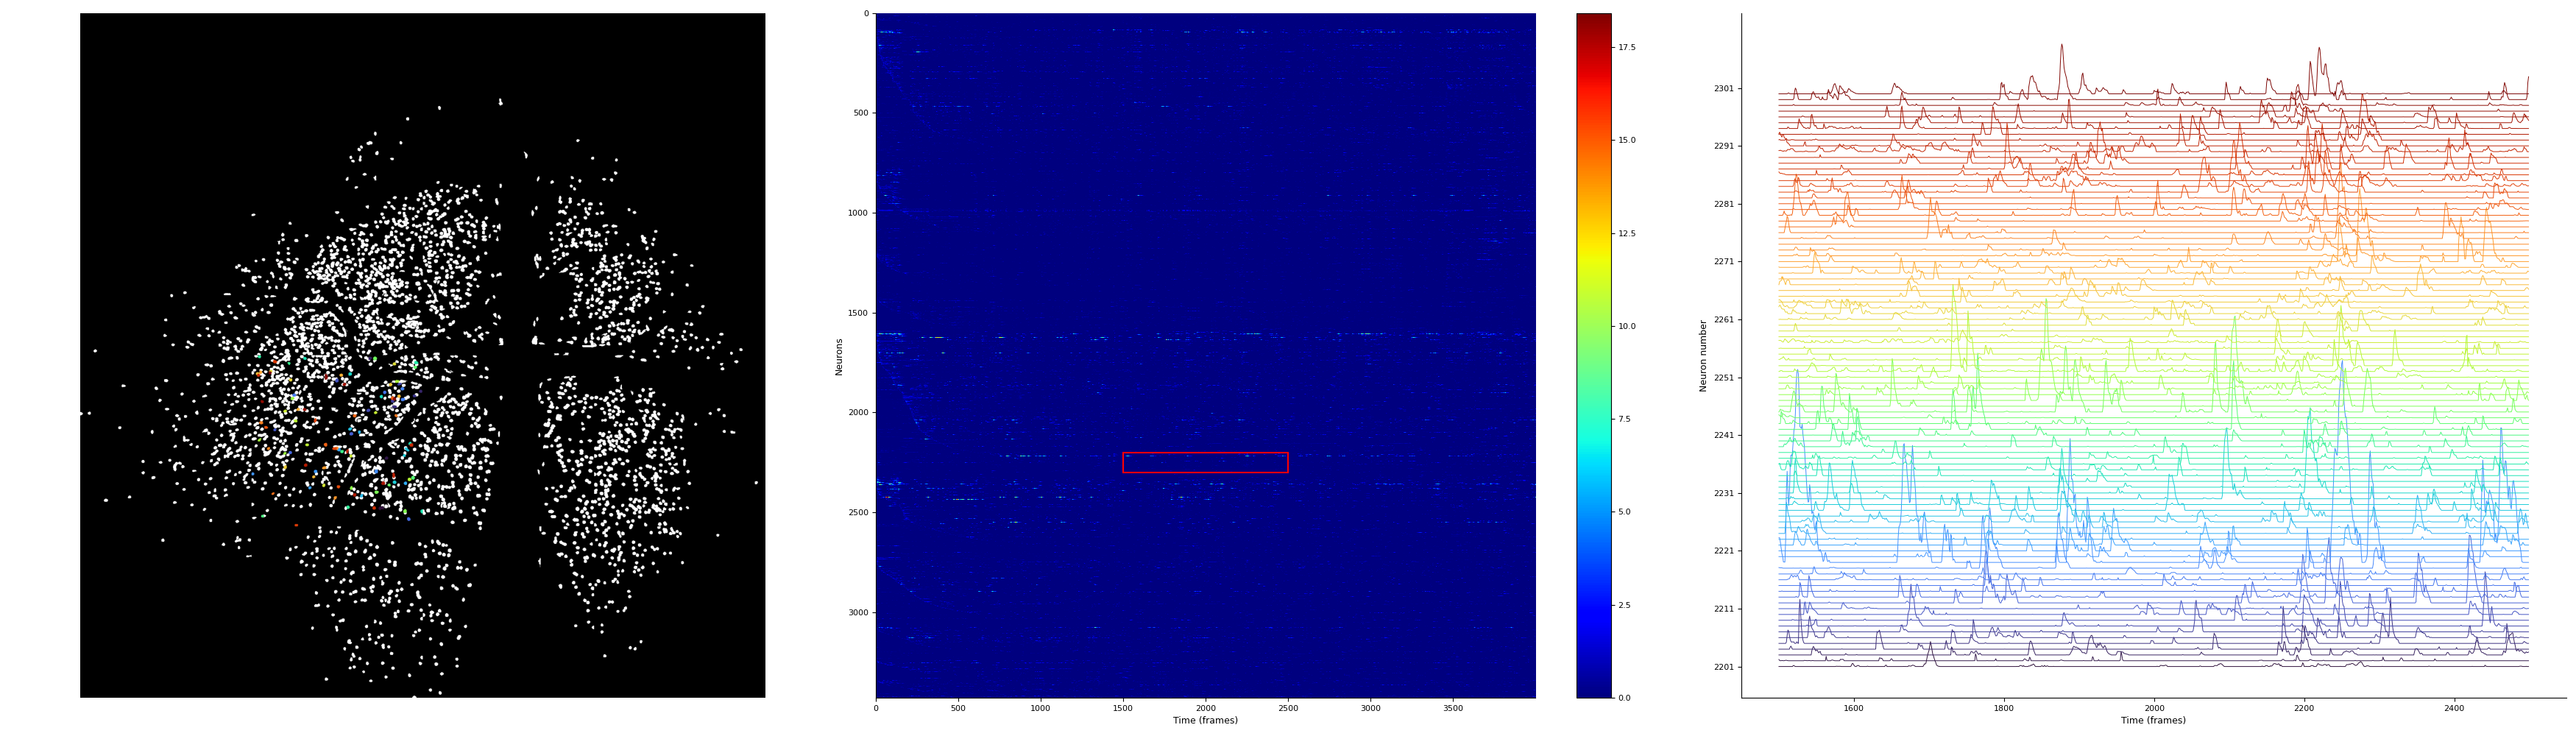

In [27]:
display_existing_image(Path(paths.seg_out) / "Neuron_trace" / "2201_to_2300.png", title="Neuron traces (first 100 neurons)")

## 3. Final Spatial Outputs

Filtered summed ROI mask


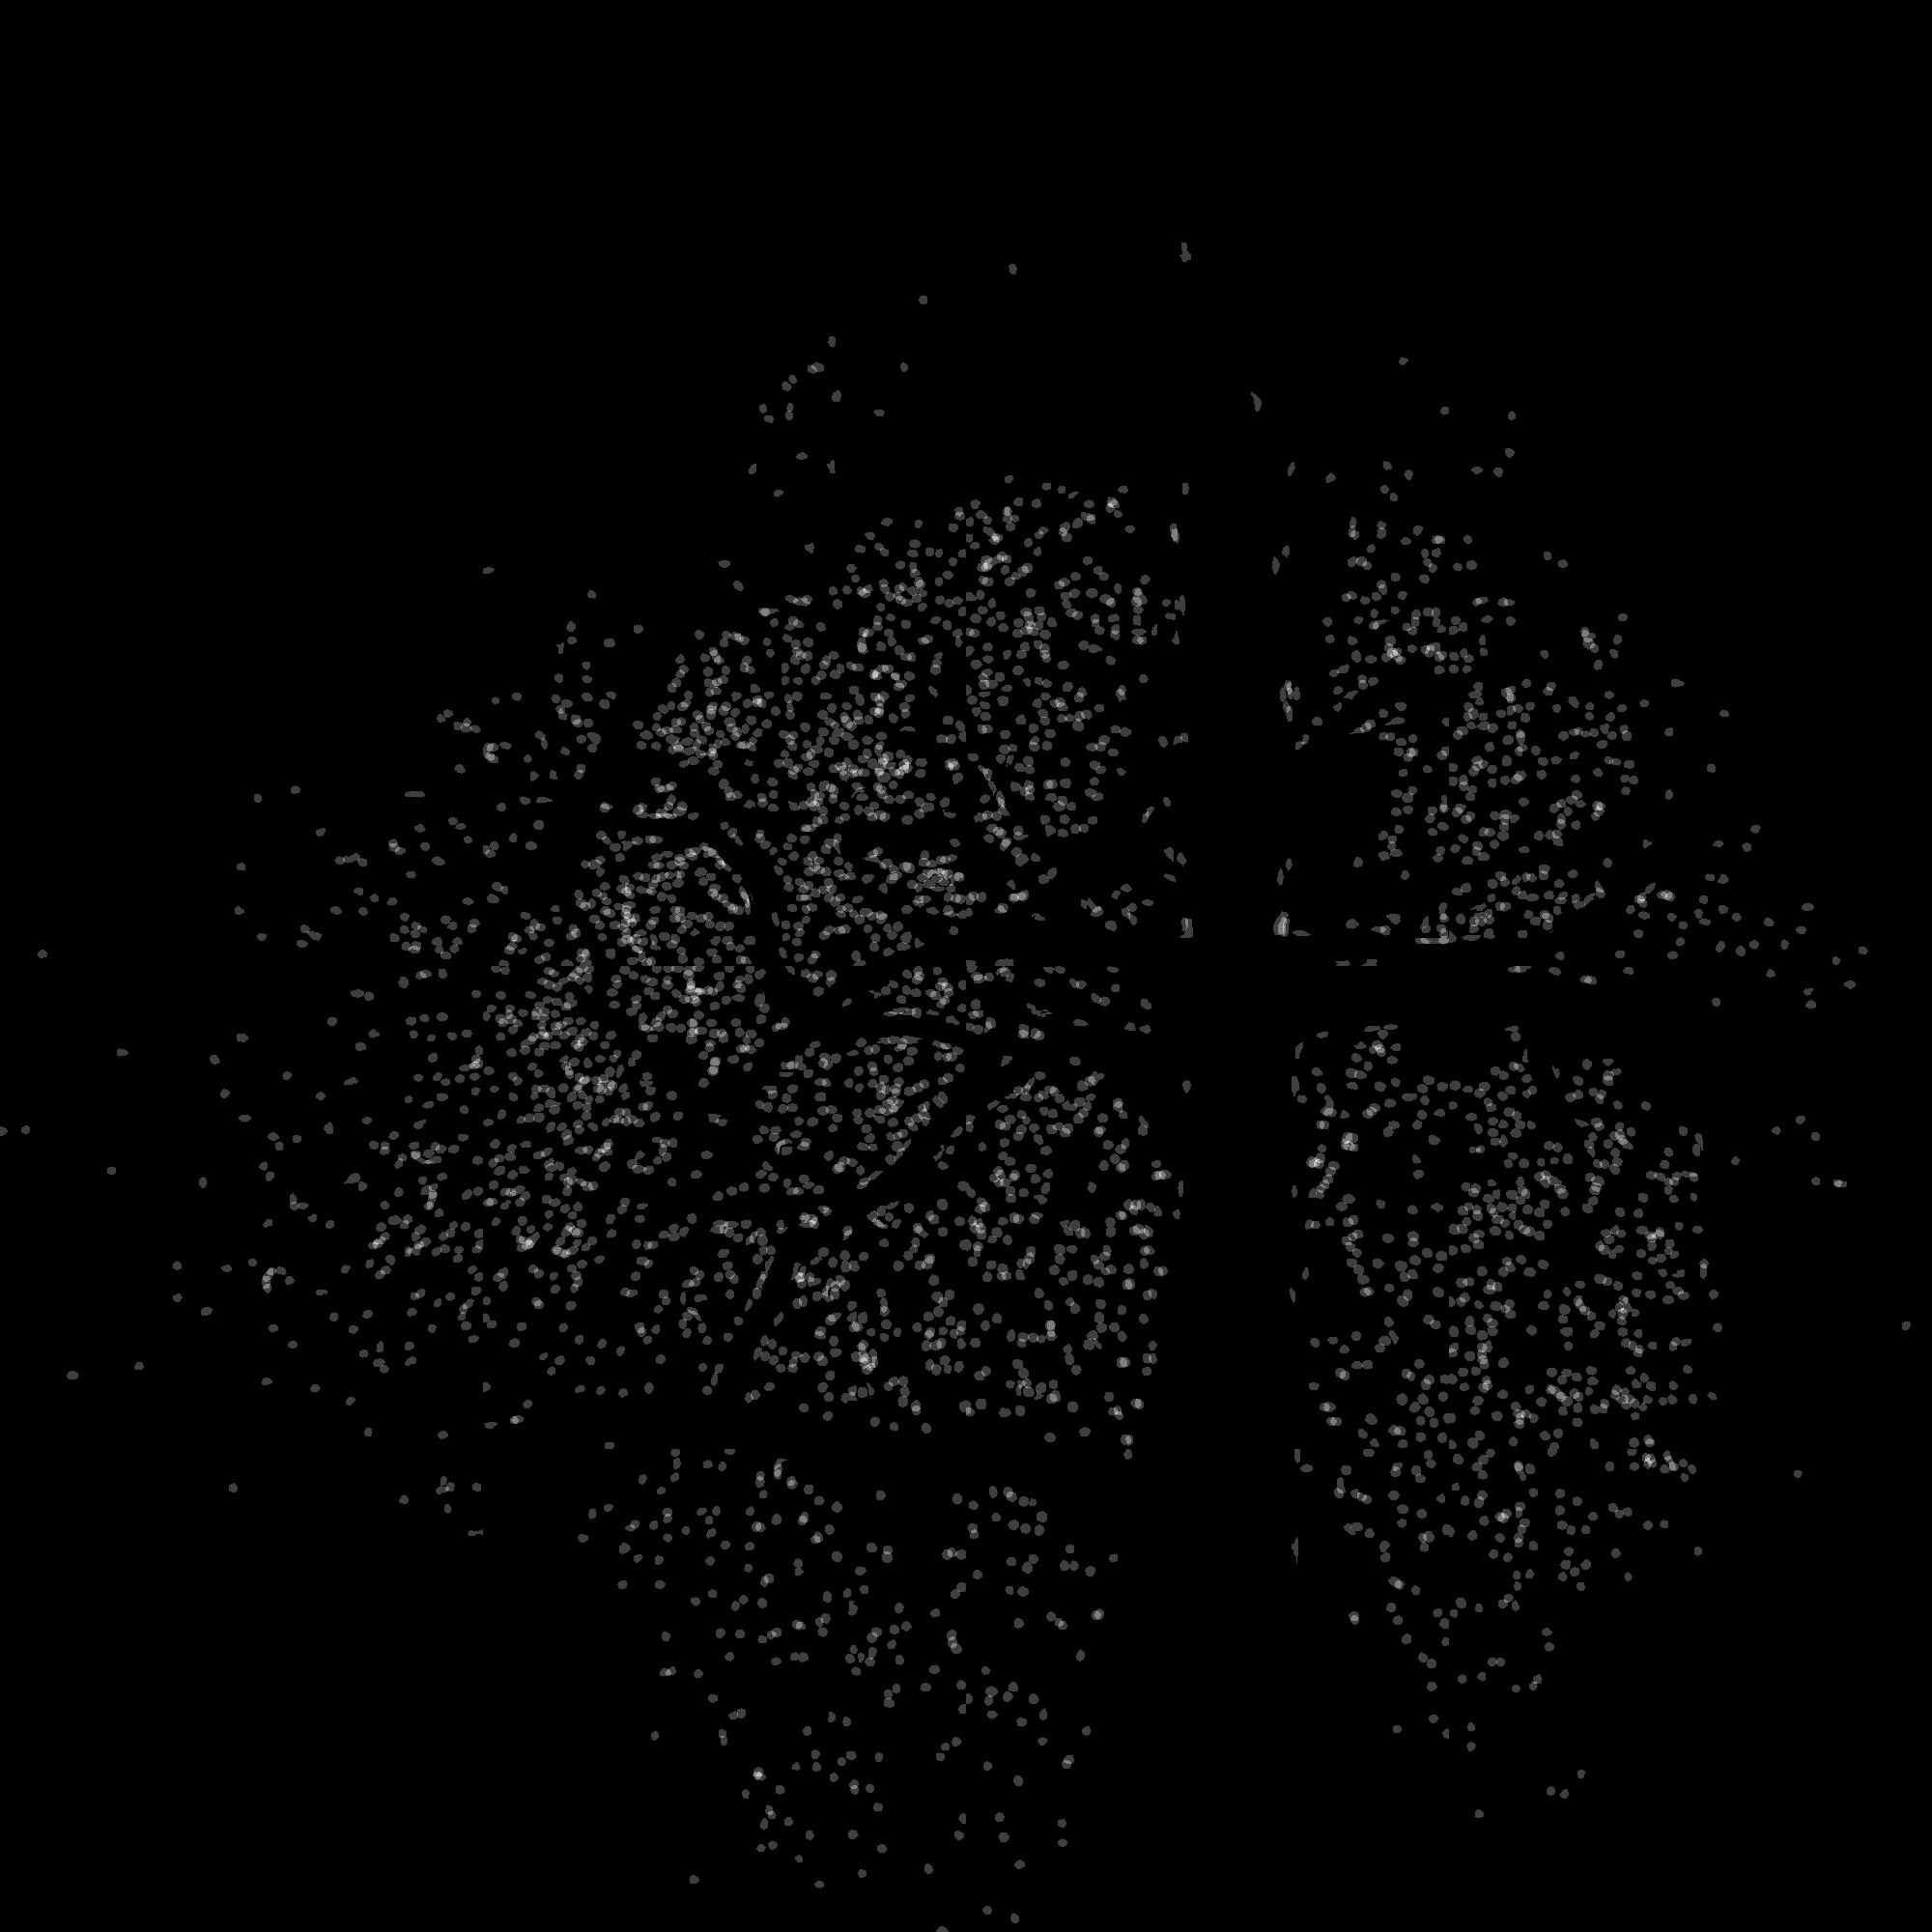

Output directory: /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1
SEG_SUM.png
SEG_SUM_filtered.png
cm.mat
cm.png
cm.svg
cm_filtered.mat
cm_wo_vessel.png
cm_wo_vessel.svg
infer_results.mat
infer_results_filtered.mat
neuron_mask.png
neuron_mask.svg
seg_results.mat
seg_results_filtered.mat


[PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1/SEG_SUM.png'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1/SEG_SUM_filtered.png'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1/cm.mat'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1/cm.png'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1/cm.svg'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1/cm_filtered.mat'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1/cm_wo_vessel.png'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1/cm_wo_vessel.svg'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1/infer_results.mat'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_d

In [22]:
# Inspect final spatial outputs written by export_calcium_results.
display_existing_image(Path(paths.seg_out) / "SEG_SUM_filtered.png", title="Filtered summed ROI mask")
list_stage_outputs(paths.seg_out, patterns=("*.png", "*.svg", "*.mat"), max_items=80)

### Visualize neuron segment mask overlayed with background rejection projection

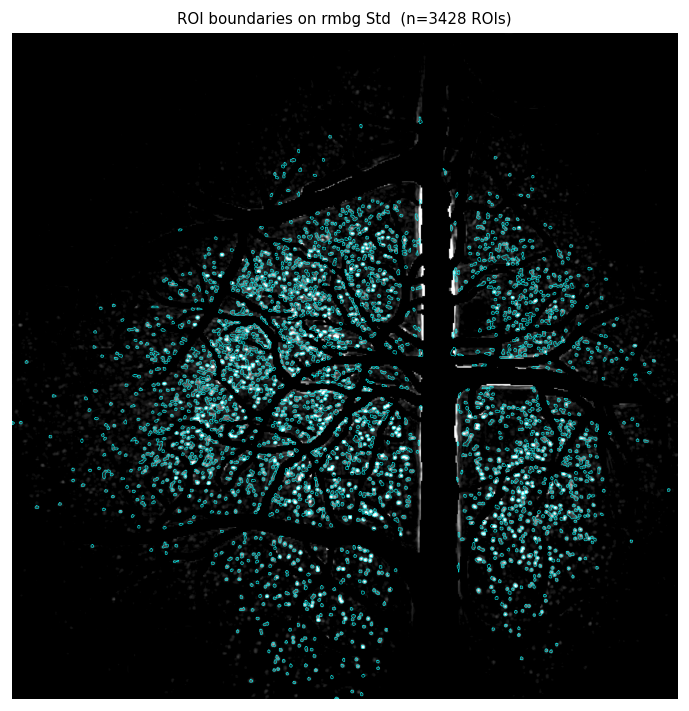

In [24]:
# Build an overlay of final ROI boundaries on the neuron-enhanced movie variance projection.
import cv2
from Airscope_ca.segmentation.segment import load_sparse_frames_from_mat  
A_filtered = np.array(load_sparse_frames_from_mat(paths.seg_out + '/seg_results_filtered.mat'))


# ── Build boundary from A ───────────────────────────────────────────────────
# If A is flattened (n_rois, d1*d2), reshape first:
# A_bool = np.asarray(A, dtype=bool).reshape(-1, d1, d2)
A_bool = np.asarray(A_filtered, dtype=bool)           # (n_rois, d1, d2)
union_mask = A_bool.any(axis=0).astype(np.uint8)
contours, _ = cv2.findContours(union_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# ── Compute std projection from background-removed movie ───────────────────
N_STD = 256
rmbg_arr = open_zarr_array(paths.rmbg_zarr_path, mode="r")
idx = sample_indices(rmbg_arr.shape[0], n=N_STD)
rmbg_frames = rmbg_arr.oindex[idx.tolist()].astype(np.float32)
rmbg_std = rmbg_frames.std(axis=0)          # (d1, d2)

# Remove vessel region from display
# Remove vessel region from display (same logic as final export stage)
vessel_mask_disp = cv2.resize(
    vessel_mask.astype(np.uint8), (rmbg_std.shape[1], rmbg_std.shape[0]), interpolation=cv2.INTER_NEAREST
)

# 1) connected-component cleanup: keep only components with area >= 300
min_size = 300
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(vessel_mask_disp)
filtered_mask = np.zeros_like(vessel_mask_disp, dtype=np.uint8)
for lab in range(1, num_labels):
    if stats[lab, cv2.CC_STAT_AREA] >= min_size:
        filtered_mask[labels == lab] = 1

# 2) dilation: 7x7 kernel, 1 iteration
vessel_mask_dilate = cv2.dilate(
    filtered_mask.astype(np.float32),
    np.ones((7, 7), np.uint8),
    iterations=1,
) > 0

rmbg_std_no_vessel = rmbg_std.copy()
rmbg_std_no_vessel[vessel_mask_dilate] = 0


# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
vmin, vmax = robust_limits(rmbg_std_no_vessel, low=0.5, high=99.5)
ax.imshow(rmbg_std_no_vessel, cmap="gray", vmin=vmin, vmax=vmax)
for cnt in contours:
    pts = cnt[:, 0, :]
    ax.plot(np.append(pts[:, 0], pts[0, 0]),
            np.append(pts[:, 1], pts[0, 1]),
            lw=0.4, color="cyan", alpha=0.8)
ax.set_title(f"ROI boundaries on rmbg Std  (n={A_bool.shape[0]} ROIs)", fontsize=9)
ax.axis("off")
fig.tight_layout()
plt.show()